In [15]:
# Installing packages and Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

data = pd.read_csv('../data/kyle_schwarber_full_data.csv')
data['hits'] = data['events'].isin(['single', 'double', 'triple', 'home_run'])
data['zone'] = data['zone'].astype('category')
data['pitch_number'] = data['pitch_number'].astype('category')
data['pitch_count'] = data['balls'].astype(str) + '-' + data['strikes'].astype(str)

features = ['zone', 'p_throws', 'pitch_count', 'effective_speed', 'release_spin_rate', 'pitch_number', 'pitch_name', 'hits']
data = data[features]
data = data.dropna()

In [16]:
# Plot Code:
from matplotlib.lines import Line2D
target_map = {str(i): f"Cluster {i}" for i in range(10)}

def plot_cluster_embedding(embedding, cluster_labels, title, x_label="Component 1", y_label="Component 2"):
    cluster_ids = np.asarray(cluster_labels, dtype=int)
    unique_clusters = np.unique(cluster_ids)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=cluster_ids,
        cmap="tab10",
        s=6,
        alpha=0.5,
    )
    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor=scatter.cmap(scatter.norm(cluster_id)),
            markeredgecolor="none",
            markersize=6,
            alpha=0.8,
        )
        for cluster_id in unique_clusters
    ]
    legend_labels = [f"Cluster {cluster_id}" for cluster_id in unique_clusters]
    plt.legend(handles, legend_labels, title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()

In [17]:
X = pd.DataFrame(data.drop(columns=['hits']))
y = pd.Series(data['hits'], name='target')

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 307, stratify = y)


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', KMeans(n_clusters = 10, random_state = 307))
])

X_transformed = model.fit_transform(X_train)
kmeans_labels = model.named_steps['classifier'].labels_

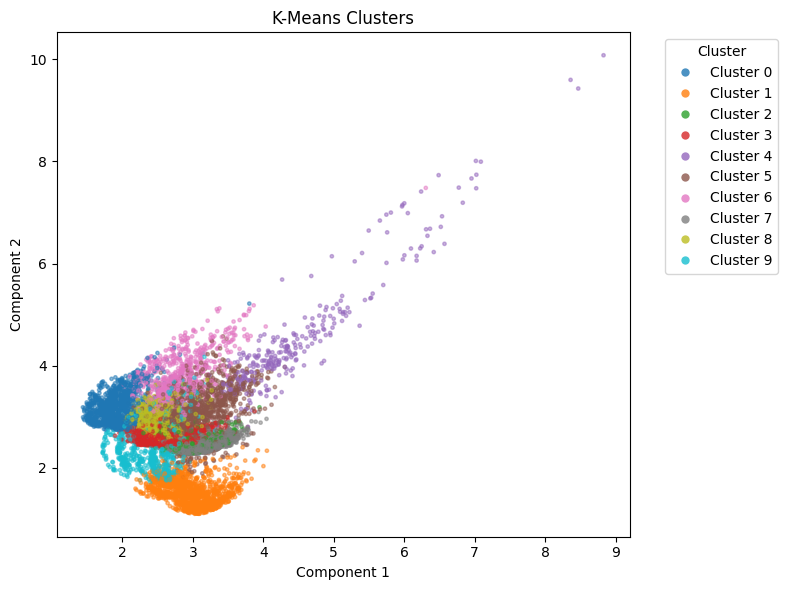

In [19]:
plot_cluster_embedding(X_transformed, kmeans_labels,  title="K-Means Clusters")

In [20]:
cluster_summary = pd.DataFrame({
    'cluster': kmeans_labels,
    'hit': y_train.values
})

cluster_rates = (
    cluster_summary
    .groupby('cluster')['hit']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'hit_rate', 'count': 'n_pitches'})
    .sort_values('hit_rate', ascending=False)
)

print(cluster_rates)

         hit_rate  n_pitches
cluster                     
3        0.067287       1397
7        0.056293       1581
5        0.045694       1138
2        0.045517        725
6        0.044720        805
8        0.044271       1152
1        0.040890       1394
0        0.035138       1053
4        0.024138        290
9        0.021250        800


In [21]:
X_train_clusters = X_train.copy()
X_train_clusters['cluster'] = kmeans_labels

num_summary = (
    X_train_clusters
    .groupby('cluster')[['effective_speed', 'release_spin_rate']]
    .mean()
)

print(num_summary)

         effective_speed  release_spin_rate
cluster                                    
0              83.813770        2358.739791
1              93.520947        2235.577475
2              93.437793        2290.466207
3              93.210093        2221.070866
4              82.319655        1073.131034
5              86.601054        1717.891037
6              78.613416        2701.554037
7              94.931879        2280.620493
8              86.809115        2441.297743
9              83.754500        2390.817500


In [22]:
pitch_type_summary = (
    X_train_clusters
    .groupby('cluster')['pitch_name']
    .agg(lambda x: x.value_counts().index[0])
)

print(pitch_type_summary)

cluster
0             Slider
1    4-Seam Fastball
2    4-Seam Fastball
3    4-Seam Fastball
4       Split-Finger
5           Changeup
6          Curveball
7    4-Seam Fastball
8             Slider
9             Slider
Name: pitch_name, dtype: object


In [23]:
zone_summary = (
    X_train_clusters
    .groupby('cluster')['zone']
    .agg(lambda x: x.value_counts().index[0])
)

print(zone_summary)

cluster
0    13.0
1    11.0
2    11.0
3    13.0
4    13.0
5    13.0
6    14.0
7    11.0
8    14.0
9    13.0
Name: zone, dtype: category
Categories (13, float64): [1.0, 2.0, 3.0, 4.0, ..., 11.0, 12.0, 13.0, 14.0]


In [24]:
count_summary = (
    X_train_clusters
    .groupby('cluster')['pitch_count']
    .agg(lambda x: x.value_counts().index[0])
)

print(count_summary)

cluster
0    0-1
1    0-0
2    1-0
3    1-0
4    0-0
5    1-1
6    2-2
7    1-1
8    1-1
9    0-0
Name: pitch_count, dtype: object


In [25]:
summary = X_train_clusters.groupby('cluster').agg({
    'effective_speed': 'mean',
    'release_spin_rate': 'mean',
    'pitch_name': lambda x: x.value_counts().index[0],
    'zone': lambda x: x.value_counts().index[0],
    'pitch_count': lambda x: x.value_counts().index[0]
})

print(summary)

         effective_speed  release_spin_rate       pitch_name  zone pitch_count
cluster                                                                       
0              83.813770        2358.739791           Slider  13.0         0-1
1              93.520947        2235.577475  4-Seam Fastball  11.0         0-0
2              93.437793        2290.466207  4-Seam Fastball  11.0         1-0
3              93.210093        2221.070866  4-Seam Fastball  13.0         1-0
4              82.319655        1073.131034     Split-Finger  13.0         0-0
5              86.601054        1717.891037         Changeup  13.0         1-1
6              78.613416        2701.554037        Curveball  14.0         2-2
7              94.931879        2280.620493  4-Seam Fastball  11.0         1-1
8              86.809115        2441.297743           Slider  14.0         1-1
9              83.754500        2390.817500           Slider  13.0         0-0


In [26]:
cluster_summary = X_train_clusters.copy()
cluster_summary['hit'] = y_train.values

cluster_summary.groupby('cluster').agg({
    'hit': 'mean',
    'effective_speed': 'mean',
    'pitch_name': lambda x: x.value_counts().index[0],
    'zone': lambda x: x.value_counts().index[0]
})

,hit,effective_speed,pitch_name,zone
cluster,,,,
0,0.035138,83.813770,Slider,13.0
1,0.040890,93.520947,4-Seam Fastball,11.0
2,0.045517,93.437793,4-Seam Fastball,11.0
3,0.067287,93.210093,4-Seam Fastball,13.0
4,0.024138,82.319655,Split-Finger,13.0
5,0.045694,86.601054,Changeup,13.0
6,0.044720,78.613416,Curveball,14.0
7,0.056293,94.931879,4-Seam Fastball,11.0
8,0.044271,86.809115,Slider,14.0
